# Supervised: predicting loan risk

Loan `status` is the one label in this dataset that isn't manufactured
from the same features used to predict it - it's a real, independently
recorded outcome (whether the loan was repaid). Restricting to the 682
accounts that actually took out a loan, and predicting `B`/`D` (loan not
repaid / in debt, 76 accounts, 11.1%) from the account's transaction
behavior *before* that outcome is known in the modeling sense - a
legitimate supervised task, unlike predicting a cluster ID back from
its own input features.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score)

features = pd.read_csv('outputs/account_features.csv')
with open('outputs/feature_list.json') as f:
    feature_cols = json.load(f)

loan = pd.read_csv('data/loan.asc', sep = ';')
loan['bad'] = loan['status'].isin(['B', 'D']).astype(int)

data = features.merge(loan[['account_id', 'bad']], on = 'account_id', how = 'inner')
data.shape, data['bad'].value_counts()

((682, 17),
 bad
 0    606
 1     76
 Name: count, dtype: int64)

`has_loan` is trivially 1 for every row here (that's the filter condition) so it's dropped - keeping it would be a constant column, not a leak, but still dead weight.

In [2]:
model_features = [c for c in feature_cols if c != 'has_loan']
X = data[model_features]
y = data['bad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, stratify = y, random_state = 42)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((511, 14),
 (171, 14),
 np.float64(0.11154598825831702),
 np.float64(0.1111111111111111))

Both models are wrapped in a `Pipeline` so scaling is fit on the training fold only, every time - no leakage from scaling on the full dataset before splitting.

In [3]:
models = {
    'Logistic Regression (balanced)': Pipeline([
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)),
    ]),
    'Random Forest (balanced)': Pipeline([
        ('scale', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators = 300, class_weight = 'balanced', random_state = 42)),
    ]),
}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv = cv, scoring = 'average_precision')
    cv_results[name] = scores
    print(f'{name:32s} PR-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})')

Logistic Regression (balanced)   PR-AUC = 0.789 (+/- 0.048)


Random Forest (balanced)         PR-AUC = 0.769 (+/- 0.071)


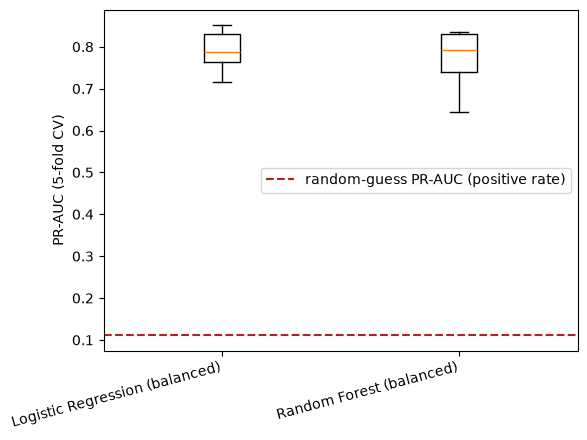

In [4]:
fig, ax = plt.subplots(figsize = (6, 4.5))
ax.boxplot(cv_results.values(), tick_labels = cv_results.keys())
ax.axhline(y_train.mean(), color = 'firebrick', linestyle = '--', label = 'random-guess PR-AUC (positive rate)')
ax.set_ylabel('PR-AUC (5-fold CV)')
ax.legend()
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.savefig('outputs/cv_comparison.png', dpi = 120)
plt.show()

PR-AUC (not ROC-AUC or accuracy) is the right headline metric here - with only 11% positives, a model that just predicts "good loan" every time gets 89% accuracy while catching zero bad loans. PR-AUC's baseline is the positive rate itself, so it's harder to look good by accident.

In [5]:
best_name = max(cv_results, key = lambda k: cv_results[k].mean())
best_model = models[best_name]
best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print(f'best model: {best_name}')
print(classification_report(y_test, y_pred, target_names = ['good', 'bad'], digits = 3))
print(f'test PR-AUC: {average_precision_score(y_test, y_prob):.3f}')
print(f'test ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

best model: Logistic Regression (balanced)
              precision    recall  f1-score   support

        good      0.986     0.908     0.945       152
         bad      0.548     0.895     0.680        19

    accuracy                          0.906       171
   macro avg      0.767     0.901     0.813       171
weighted avg      0.937     0.906     0.916       171

test PR-AUC: 0.847
test ROC-AUC: 0.962


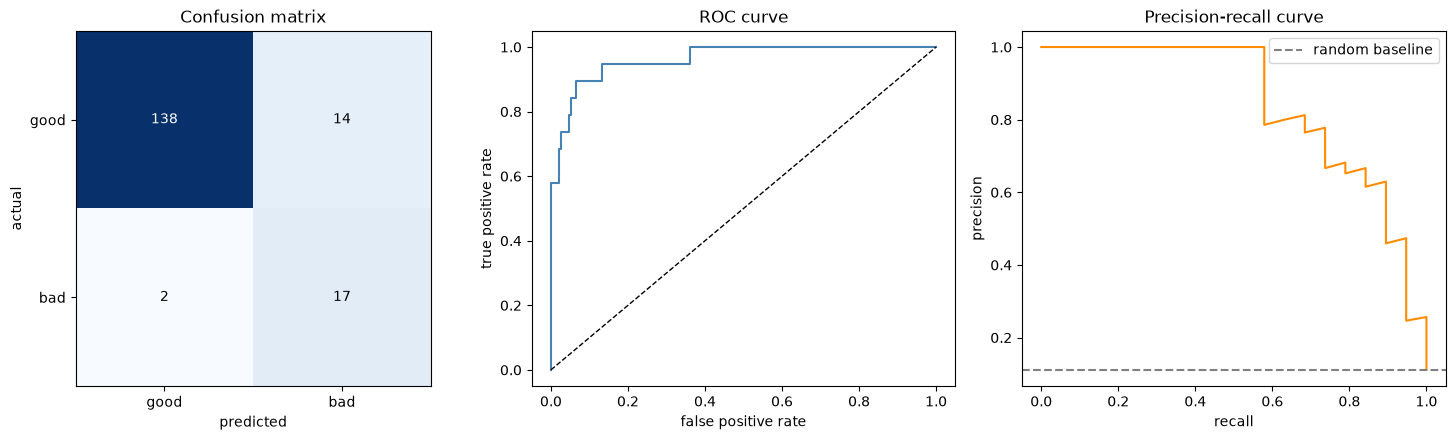

In [6]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4.5))

cm = confusion_matrix(y_test, y_pred)
axes[0].imshow(cm, cmap = 'Blues')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha = 'center', va = 'center',
                     color = 'white' if cm[i, j] > cm.max() / 2 else 'black')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['good', 'bad'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['good', 'bad'])
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('actual')
axes[0].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color = 'steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth = 1)
axes[1].set_title('ROC curve')
axes[1].set_xlabel('false positive rate'); axes[1].set_ylabel('true positive rate')

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, color = 'darkorange')
axes[2].axhline(y_test.mean(), color = 'gray', linestyle = '--', label = 'random baseline')
axes[2].set_title('Precision-recall curve')
axes[2].set_xlabel('recall'); axes[2].set_ylabel('precision')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/loan_risk_evaluation.png', dpi = 120)
plt.show()

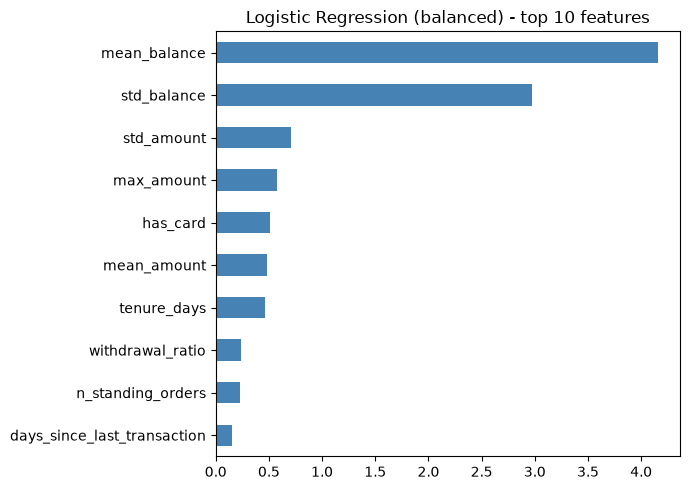

In [7]:
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = pd.Series(best_model.named_steps['clf'].feature_importances_, index = model_features)
else:
    importances = pd.Series(np.abs(best_model.named_steps['clf'].coef_[0]), index = model_features)
importances = importances.sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (7, 5))
importances.head(10).plot.barh(ax = ax, color = 'steelblue')
ax.invert_yaxis()
ax.set_title(f'{best_name} - top 10 features')
plt.tight_layout()
plt.savefig('outputs/loan_risk_feature_importance.png', dpi = 120)
plt.show()

Cross-checking against the unsupervised anomaly flags from the previous notebook - do the accounts this supervised model scores as high-risk overlap with the ones the unsupervised methods flagged as behaviorally unusual, completely independently?

In [8]:
anomalies = pd.read_csv('outputs/account_features_with_anomalies.csv')[['account_id', 'iso_anomaly', 'lof_anomaly']]

test_ids = data.loc[X_test.index, 'account_id']
test_results = pd.DataFrame({'account_id': test_ids.values, 'risk_prob': y_prob, 'actual_bad': y_test.values})
test_results = test_results.merge(anomalies, on = 'account_id', how = 'left')

high_risk = test_results['risk_prob'] > test_results['risk_prob'].quantile(0.85)
anomaly_rate_high_risk = (test_results.loc[high_risk, 'iso_anomaly'] | test_results.loc[high_risk, 'lof_anomaly']).mean()
anomaly_rate_rest = (test_results.loc[~high_risk, 'iso_anomaly'] | test_results.loc[~high_risk, 'lof_anomaly']).mean()

pd.Series({
    'flagged-as-anomalous rate, top 15% predicted risk': anomaly_rate_high_risk,
    'flagged-as-anomalous rate, rest': anomaly_rate_rest,
})

flagged-as-anomalous rate, top 15% predicted risk    0.230769
flagged-as-anomalous rate, rest                      0.227586
dtype: float64

In [9]:
os.makedirs('outputs', exist_ok = True)
results = {
    'best_model': best_name,
    'cv_pr_auc_mean': {k: float(v.mean()) for k, v in cv_results.items()},
    'test_pr_auc': float(average_precision_score(y_test, y_prob)),
    'test_roc_auc': float(roc_auc_score(y_test, y_prob)),
    'test_positive_rate': float(y_test.mean()),
    'top_features': importances.head(5).to_dict(),
}
with open('outputs/loan_risk_results.json', 'w') as f:
    json.dump(results, f, indent = 2)

results

{'best_model': 'Logistic Regression (balanced)',
 'cv_pr_auc_mean': {'Logistic Regression (balanced)': 0.7890769011903725,
  'Random Forest (balanced)': 0.7686476282207094},
 'test_pr_auc': 0.8473070117460697,
 'test_roc_auc': 0.9619113573407201,
 'test_positive_rate': 0.1111111111111111,
 'top_features': {'mean_balance': 4.157286599589541,
  'std_balance': 2.9718904399132726,
  'std_amount': 0.7123312170213417,
  'max_amount': 0.5742161585816034,
  'has_card': 0.5127355943436084}}